## 1. Importing PyTorch and setting up device-agnostic code

In [2]:
# Install necessary packages
!pip install efficientnet-pytorch torchinfo

# Import libraries
import torch
from torch import nn
from pathlib import Path
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm
from efficientnet_pytorch import EfficientNet
from torchinfo import summary

# Continue with the rest of your code

import torch
from torch import nn

print(torch.__version__)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16428 sha256=14f9b39a269a1dfbb612f50675274c071ed9b2c8d0c35b10f3a686f20c575772
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet-pytorch
2.1.2
cuda


## 2. Data Preparation 

In [3]:
"""Commented this just to check the path for datasets"""
# from pathlib import Path
# import os

# # Setup path to data folder
# image_path = Path("../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/")

# def walk_through_dir(dir_path):
#   """Walks through dir_path returning its contents."""
#   for dirpath, dirnames, filenames in os.walk(dir_path):
#     print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

# walk_through_dir(image_path)

'Commented this just to check the path for datasets'

## 3. Data Visualization

Random image path: ../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/T/T (1163).jpg
Image Class: T
Image Height: 200
Image Width: 200


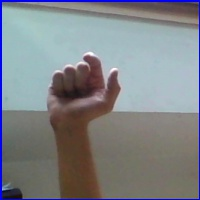

In [4]:
from pathlib import Path
import os
import random
from PIL import Image

# random.seed(42)
image_path = Path("../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/")
image_path_list = list(image_path.glob("*/*/*.jpg"))
# print(len(image_path_list))
random_image_path = random.choice(image_path_list)
# print(random_image_path)
# the image class is the name of the directory where iamges resides
image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)

# Print metadata
print(f'Random image path: {random_image_path}')
print(f'Image Class: {image_class}')
print(f'Image Height: {img.height}')
print(f'Image Width: {img.width}')
img

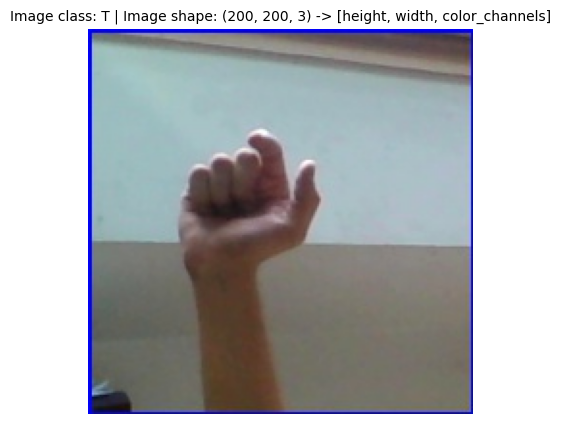

In [5]:
# Visualizing using matplotliib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
fig = plt.figure(figsize=(6, 5))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]", fontsize = 10)
plt.axis(False)
plt.show()

In [6]:
img_as_array

array([[[  0,   3, 252],
        [  0,   9, 255],
        [  0,   2, 241],
        ...,
        [  8,   0, 246],
        [  0,   0, 242],
        [  0,   5, 247]],

       [[  0,   6, 255],
        [  0,   1, 234],
        [  3,  11, 208],
        ...,
        [ 11,   2, 193],
        [ 10,   8, 216],
        [  1,   4, 219]],

       [[  0,   0, 250],
        [  8,   8, 216],
        [ 90,  97, 213],
        ...,
        [ 90,  81, 162],
        [ 78,  72, 208],
        [ 10,   8, 171]],

       ...,

       [[  7,   0, 253],
        [  9,   5, 203],
        [ 21,  21, 111],
        ...,
        [109, 105, 120],
        [105, 105, 195],
        [  8,  12, 138]],

       [[  0,   0, 248],
        [  2,   2, 212],
        [ 12,  11, 151],
        ...,
        [107, 107, 197],
        [ 95,  99, 232],
        [  6,  15, 170]],

       [[  1,   3, 248],
        [  2,   5, 222],
        [ 13,  12, 176],
        ...,
        [ 13,  14, 140],
        [  6,  12, 168],
        [  3,  14, 182]]

## 4. Transforming data

In [7]:
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

print(torchvision.__version__)

# Transform image
data_transform = transforms.Compose([
    transforms.Resize(size = (128, 128)),         # Resize our images to 224x224
    transforms.ToTensor()
])


transformed_data = data_transform(img)
transformed_data, transformed_data.shape, transformed_data.dtype

0.16.2


(tensor([[[0.0000, 0.0039, 0.0196,  ..., 0.0314, 0.0314, 0.0078],
          [0.0118, 0.2000, 0.2902,  ..., 0.2588, 0.2510, 0.1098],
          [0.0235, 0.2941, 0.4118,  ..., 0.3059, 0.2941, 0.1412],
          ...,
          [0.0235, 0.0902, 0.1216,  ..., 0.4784, 0.4510, 0.2000],
          [0.0235, 0.0627, 0.0745,  ..., 0.4510, 0.4235, 0.1804],
          [0.0039, 0.0392, 0.0471,  ..., 0.1961, 0.1882, 0.0745]],
 
         [[0.0196, 0.0235, 0.0118,  ..., 0.0118, 0.0078, 0.0157],
          [0.0118, 0.2196, 0.3098,  ..., 0.2196, 0.2235, 0.1020],
          [0.0118, 0.3294, 0.4588,  ..., 0.2588, 0.2627, 0.1333],
          ...,
          [0.0157, 0.0902, 0.1294,  ..., 0.4549, 0.4353, 0.2039],
          [0.0078, 0.0588, 0.0745,  ..., 0.4314, 0.4157, 0.1961],
          [0.0118, 0.0353, 0.0431,  ..., 0.2000, 0.1961, 0.1059]],
 
         [[0.9843, 0.9098, 0.8706,  ..., 0.8863, 0.8902, 0.9176],
          [0.9373, 0.8039, 0.6824,  ..., 0.5765, 0.6627, 0.7451],
          [0.9020, 0.7020, 0.5098,  ...,

## 5. Loading data with ImageFolder and Split into Train and Test Data

In [8]:
# Setup source directory
source_dir = '../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/'

source_data = datasets.ImageFolder(root = source_dir,
                                  transform = data_transform, # Transforms input data into tensors
                                  target_transform = None)    # Transform labels into none

source_data

Dataset ImageFolder
    Number of datapoints: 223074
    Root location: ../input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train/
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=warn)
               ToTensor()
           )

In [9]:
from torch.utils.data import random_split

train_size = int(0.8 * len(source_data))
test_size = len(source_data) - train_size

# Split the dataset into train and test sets
train_data, test_data = random_split(source_data, [train_size, test_size])

print(f"Train set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

Train set size: 178459
Test set size: 44615


In [10]:
# Get class names as list and dict 
class_names = source_data.classes
class_dict = source_data.class_to_idx
class_dict

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 'del': 26,
 'nothing': 27,
 'space': 28}

In [11]:
# Index on the train_data Dataset to get a single iamge and label
img, label = train_data[0][0], train_data[0][1]

img, img.dtype, label, type(label), class_names[label]

(tensor([[[0.0039, 0.0196, 0.0196,  ..., 0.0314, 0.0314, 0.0078],
          [0.0275, 0.2157, 0.3098,  ..., 0.3569, 0.4039, 0.1843],
          [0.0235, 0.3294, 0.4706,  ..., 0.4314, 0.4314, 0.2078],
          ...,
          [0.0157, 0.2078, 0.3098,  ..., 0.4275, 0.3961, 0.1765],
          [0.0196, 0.2118, 0.2980,  ..., 0.4039, 0.3804, 0.1608],
          [0.0078, 0.0980, 0.1451,  ..., 0.1765, 0.1647, 0.0667]],
 
         [[0.0039, 0.0078, 0.0118,  ..., 0.0118, 0.0078, 0.0118],
          [0.0118, 0.2078, 0.3137,  ..., 0.3255, 0.3686, 0.1804],
          [0.0078, 0.3294, 0.4784,  ..., 0.3725, 0.3804, 0.1804],
          ...,
          [0.0118, 0.2196, 0.3216,  ..., 0.4078, 0.3882, 0.1882],
          [0.0078, 0.2157, 0.3098,  ..., 0.4000, 0.3843, 0.1765],
          [0.0118, 0.0980, 0.1451,  ..., 0.1922, 0.1804, 0.0980]],
 
         [[0.9647, 0.9020, 0.8667,  ..., 0.8824, 0.9020, 0.9176],
          [0.9176, 0.7804, 0.6627,  ..., 0.6706, 0.7961, 0.7961],
          [0.8824, 0.6784, 0.4824,  ...,

In [12]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)
img.shape, img_permute.shape

(torch.Size([3, 128, 128]), torch.Size([128, 128, 3]))

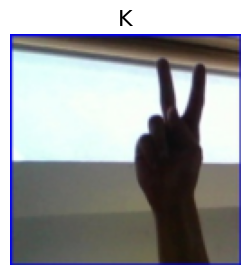

In [13]:
# Plot the image
plt.figure(figsize = (3, 3))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label], fontsize = 16); 

## 6. Turn loaded images into Dataloaders

In [14]:
# Train and test dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 192
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

len(train_dataloader), len(test_dataloader)

(930, 233)

In [15]:
img, label = next(iter(train_dataloader))

img.shape, label.shape     # {img.shape} -> [batch_size, color_channels, height, width]

(torch.Size([192, 3, 128, 128]), torch.Size([192]))

## 7. Transfer Learning using `EfficientNetB0`

In [16]:
!pip install efficientnet_pytorch torchinfo

In [17]:
from efficientnet_pytorch import EfficientNet
from torchinfo import summary

num_classes = len(class_names)    # Number of classes

# Instantiate the EfficientNet model
model = EfficientNet.from_pretrained('efficientnet-b0').to(device)
model._fc = nn.Linear(model._fc.in_features, num_classes)  

summary(model=model,
        input_size=(192, 3, 128, 128),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 156MB/s]


Loaded pretrained weights for efficientnet-b0


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [192, 3, 128, 128]   [192, 29]            --                   True
├─Conv2dStaticSamePadding (_conv_stem)                       [192, 3, 128, 128]   [192, 32, 64, 64]    864                  True
│    └─ZeroPad2d (static_padding)                            [192, 3, 128, 128]   [192, 3, 129, 129]   --                   --
├─BatchNorm2d (_bn0)                                         [192, 32, 64, 64]    [192, 32, 64, 64]    64                   True
├─MemoryEfficientSwish (_swish)                              [192, 32, 64, 64]    [192, 32, 64, 64]    --                   --
├─ModuleList (_blocks)                                       --                   --                   --                   True
│    └─MBConvBlock (0)                                       [192, 32, 64, 64]    [192, 16, 64, 

In [18]:
# Trying forward pass to check the model
model(img.to(device))

tensor([[ 0.0675,  0.1794,  0.0016,  ..., -0.0687, -0.2059,  0.2617],
        [-0.0758, -0.1316, -0.5203,  ..., -1.0142,  0.2024,  0.4671],
        [-0.1772, -0.2573, -0.0304,  ..., -0.2069,  0.1543, -0.0659],
        ...,
        [-0.0577,  0.0085,  0.1781,  ..., -0.0488,  0.4886, -0.2817],
        [ 0.0694,  0.1115, -0.2171,  ..., -0.1760,  0.2465, -0.1224],
        [-0.2458,  0.4425,  0.2342,  ..., -0.2793, -0.3609,  0.1093]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

## 8. Create Train/Test Loop Function

In [19]:
def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0, 0

    # Turn on inference
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [20]:
from tqdm.auto import tqdm

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs):
    # Create a empty results dictionar
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss":[],
               "test_acc": []}
    # Loop through training and testing steps for no of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model,
                                           dataloader = train_dataloader,
                                           optimizer = optimizer,
                                           loss_fn = loss_fn)
        test_loss, test_acc = test_step(model = model,
                                        dataloader = test_dataloader,
                                        loss_fn = loss_fn)
        print(f'Epoch: {epoch} | Train loss: {train_loss:.4f} - Train acc: {(train_acc*100):.2f}% -  Test loss: {test_loss:.4f} - Test acc: {(test_acc*100):.2f}%')
        
        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
        return results

## 9. Train and Evaluate the Model

In [21]:
# Setup loss functions and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr=0.001)

In [ ]:
# Set random seed
# torch.manual_seed(42)
EPOCHS = 5

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model
model_results = train(model = model,
                      train_dataloader = train_dataloader,
                      test_dataloader = test_dataloader,
                      optimizer = optimizer,
                      loss_fn = loss_fn,
                      epochs = EPOCHS)

# End the timer and print duration of training
end_time = timer()
print(f'Total Train Time: {end_time - start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

## 10. Plot loss curves and accuracy curves

In [ ]:
# Get the model key results
model_results.keys()

In [ ]:
def plot_loss_curves(results):
    """ Plots training curves of a results dictionary """

    # Get results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

In [ ]:
plot_loss_curves(model_results)

## 11. Saving Model

In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Create model save path
MODEL_NAME = "ASL_HandSignLang_EfficientNetB0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

## 12. Making Predictions on Loaded Model

In [ ]:
loaded_model = EfficientNet.from_pretrained('efficientnet-b0').to('cpu')
loaded_model._fc = nn.Linear(model._fc.in_features, 29)

loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# print(f"Loaded model:\n{loaded_model}")
print(f"Model on device:\n{next(loaded_model.parameters()).device}")

In [ ]:
def make_predictions(model, data, device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim = 0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim = 0)
            pred_probs.append(pred_prob.cpu())
            return torch.stack(pred_probs)

In [ ]:
import random
# random.seed(42)

test_samples = []
test_labels = []
# test_targets_tensor = torch.tensor(test_data.targets)
for sample, label in random.sample(list(test_data), k = 30):
    test_samples.append(sample)
    test_labels.append(label)

In [ ]:
loaded_pred_probs = make_predictions(loaded_model,
                                     test_samples,
                                     device)

loaded_pred_classes = loaded_pred_probs.argmax(dim = 1)

In [ ]:
plt.figure(figsize=(16, 12))
nrows, ncols = 5, 6

# Print lengths to debug
print(f"Length of loaded_pred_classes: {len(loaded_pred_classes)}")
print(f"Length of test_labels: {len(test_labels)}")
print(f"Length of test_samples: {len(test_samples)}")

# Determine the maximum number of samples to display
num_samples = min(len(loaded_pred_classes), len(test_labels), len(test_samples), nrows * ncols)

for i in range(num_samples):
    class_name = np.array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
                           'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
                           'del', 'nothing', 'space'])

    plt.subplot(nrows, ncols, i + 1)
    normalized_sample = test_samples[i].permute(1, 2, 0).numpy()  # Change this if needed
    plt.imshow(normalized_sample)

    # Ensure loaded_pred_classes[i] and test_labels[i] are valid indices
    pred_index = loaded_pred_classes[i]  # Use .item() only if it's a tensor
    truth_index = test_labels[i]  # Access directly since it's an int

    # Print out the indices to debug
    print(f"Index for prediction: {pred_index}, Index for truth: {truth_index}")

    # Check if indices are within bounds
    if pred_index < len(class_name) and truth_index < len(class_name):
        pred_label = class_name[pred_index]
        truth_label = class_name[truth_index]
    else:
        pred_label = "Unknown"
        truth_label = "Unknown"

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"  
    
    if pred_label == truth_label:
        plt.title(title_text, fontsize=9, c="g")
    else:
        plt.title(title_text, fontsize=9, c="r")

    plt.axis(False)

plt.show()
